In [1]:
import numpy
import AILibs
import matplotlib.pyplot as plt


#sampling frequency, 2kHz
dt       = 1.0/2000.0

u_max       =  1.0          # torque max value
k_motor     =  195.216         # motor constant 
rad_var     =  24.403    # (rad/s)^2 variance (encoder noise)
tau         =  0.001*17.507       # motor time constant, milliseconds
encoder_resolution = 4096




rpm_max = u_max*k_motor*60.0/(2.0*numpy.pi)

print("rpm_max = ", rpm_max)


# continuous time dynamics, 2nd order servo model
mat_a = numpy.zeros((2, 2))
mat_b = numpy.zeros((2, 1))
mat_c = numpy.eye(2)
 

mat_a[0][1] = 1.0
mat_a[1][1] = -1.0/tau    
mat_b[1][0] = k_motor*(1.0/tau)

#create continuous dynamical system (state space model)
ds = AILibs.DynamicalSystem(mat_a, mat_b, mat_c, dt)

print()
print("continuous model")
print(ds)




a_disc, b_disc, c_disc = AILibs.c2d(ds.a, ds.b, ds.c, dt)

print("discrete model")
print("a = ", a_disc)
print("b = ", b_disc)
print("\n")



rpm_max =  1864.1754822376465

continuous model
mat_a = 
0.0 1.0 
0.0 -57.12001 


mat_b = 
0.0 
11150.7397 


mat_c = 
1.0 0.0 
0.0 1.0 



discrete model
a =  [[1.00000000e+00 4.92960523e-04]
 [0.00000000e+00 9.71842090e-01]]
b =  [[1.37421862e-03]
 [5.49687447e+00]]




In [2]:
#process noise
q_noise = numpy.zeros((2, 2))
q_noise[0][0] = 1
q_noise[1][1] = 1

# measurement noise
d_theta = 2.0*numpy.pi/encoder_resolution
r_noise = numpy.zeros((2, 2))
r_noise[0][0] = ((d_theta)**2)/12
r_noise[1][1] = rad_var


kalman_filter = AILibs.KalmanFilter(a_disc, b_disc, c_disc, q_noise, r_noise)
    
print("kalman gain = ")
print(kalman_filter.k)

kalman gain = 
[[9.99999804e-01 1.28409967e-11]
 [1.59802423e-03 1.63382656e-01]]


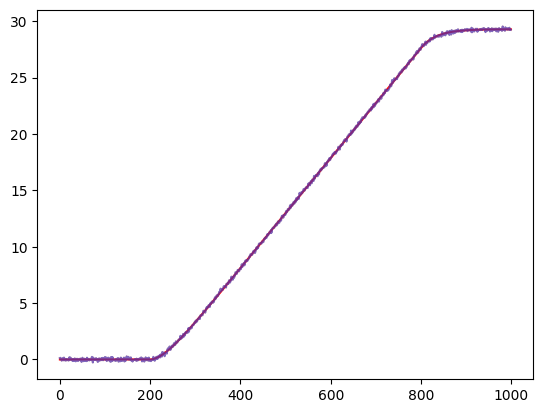

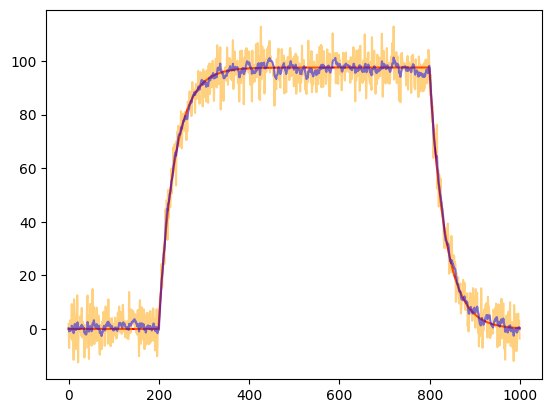

In [3]:
target_torque = 0.5

num_samples = 1000

u_in = numpy.zeros((num_samples, 1))
u_in[200:] = target_torque
u_in[800:] = 0



position_gt = numpy.zeros(num_samples)
velocity_gt = numpy.zeros(num_samples)
position_obs = position_gt + numpy.random.randn(num_samples)*0.1
velocity_obs = velocity_gt + numpy.random.randn(num_samples)*(rad_var**0.5)


x_ref = numpy.zeros((num_samples, 2))
x_obs = numpy.zeros((num_samples, 2))
x_fil = numpy.zeros((num_samples, 2))

ds.reset()

for n in range(num_samples):
    u = numpy.expand_dims(u_in[n], 0)
    x, y = ds.forward_state(u)

    x_ref[n]    = x[:, 0]

    x_obs[n, 0] = x[0, 0] + numpy.random.randn()*0.1
    x_obs[n, 1] = x[1, 0] + numpy.random.randn()*(rad_var**0.5)

   
    x_fil_ = kalman_filter.step(numpy.expand_dims(x_obs[n], 1), u)

    x_fil[n] = x_fil_[:, 0]


#for n in range(num_samples):

plt.plot(x_ref[:, 0], color="red")
plt.plot(x_obs[:, 0], alpha=0.5, color="orange")
plt.plot(x_fil[:, 0], alpha=0.5, color="blue")
plt.show()
plt.plot(x_ref[:, 1], color="red")
plt.plot(x_obs[:, 1], alpha=0.5, color="orange")
plt.plot(x_fil[:, 1], alpha=0.5, color="blue")
plt.show()


# velocity controller design

## 1. Plant Model

Define the continuous-time state-space model and discretise it at the sampling frequency $f_s = 2 \; \text{kHz}$.

$$\dot{x} = A x + B u, \quad y = C x$$

with $A = -1/\tau$, $B = k/\tau$, $C = 1$.

In [4]:

# continuous time dynamics, 1st order DC motor model
mat_a = numpy.zeros((1, 1))
mat_b = numpy.zeros((1, 1))
mat_c = numpy.eye(1)
 
mat_a[0][0] = -1.0/tau    
mat_b[0][0] = k_motor*(1.0/tau)


#create continuous dynamical system (state space model)
ds = AILibs.DynamicalSystem(mat_a, mat_b, mat_c, dt)

print("continuous model")
print(ds)

continuous model
mat_a = 
-57.12001 


mat_b = 
11150.7397 


mat_c = 
1.0 





## 2. Open-Loop Step Response

Verify the identified model by simulating the unit step response. The motor should reach steady-state velocity $\omega_{ss} = k \cdot u$ within a few time constants ($\approx 5\tau \approx 30 \; \text{ms}$).

FileNotFoundError: [Errno 2] No such file or directory: 'plots/step_response.png'

<Figure size 640x480 with 0 Axes>

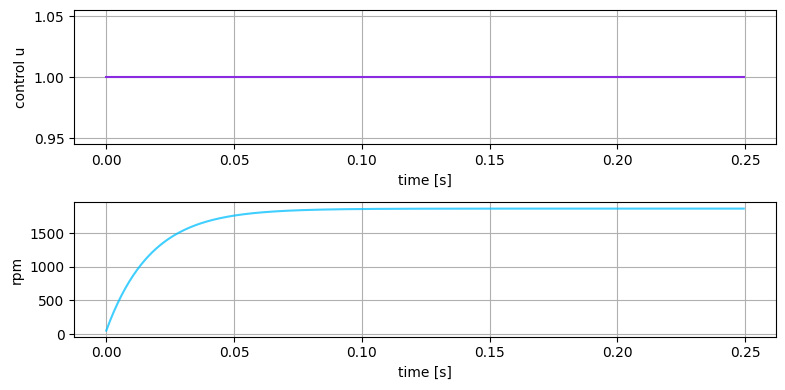

In [5]:
#compute step response
t_result = []
u_result = []
x_result = []

ds.reset()
for n in range(500):

    # unit step as input
    u = numpy.ones((1, 1))

    x, _ = ds.forward_state(u)

    t_result.append(n*dt)
    u_result.append(u[:, 0])
    x_result.append(x[:, 0])

t_result = numpy.array(t_result)
x_result = numpy.array(x_result)

#plot result
AILibs.plot_response(t_result, u_result,  x_result*60.0/(2.0*numpy.pi), "plots/step_response.png", ["control u"], ["rpm"])

# 3 LQR controller

In [ ]:
# controller syntehtize : LQR

#create loss weighting matrices (diagonal)
q = numpy.diag([10**-8] )
r = numpy.diag( [1.0 ]) 


a_disc, b_disc, c_disc = AILibs.c2d(ds.a, ds.b, ds.c, dt)

print("discrete model")
print("a = ", a_disc)
print("b = ", b_disc)   
print()
print("poles")
print(numpy.linalg.eigvals(a_disc))
print("\n") 

#solve LQR controller
lqr = AILibs.LQRIDiscrete(a_disc, b_disc, q, r, 1.0, 0.2)
    

print("controller gains")
print("Kx  = ", lqr.Kx) 
print("Ki  = ", lqr.Ki)



discrete model
a =  [[0.97612225]]
b =  [[13.66666667]]

poles
[0.97612225]


controller gains
Kx  =  [[0.00246767]]
Ki  =  [[9.83273537e-05]]


## 4. Closed-Loop Simulation

Test the LQR controller in simulation:

- **Reference:** 500 RPM step command
- **Disturbance:** At $t = 0.5 \; \text{s}$ (midpoint), a constant disturbance of $+0.1$ is added to the control input — simulating an external torque load.

The controller should:
1. Track the 500 RPM reference with zero steady-state error (integral action).
2. Reject the step disturbance and return to the commanded velocity.

<Figure size 640x480 with 0 Axes>

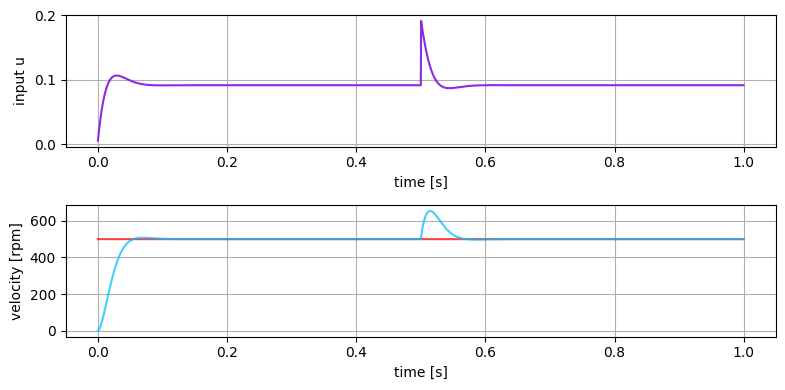

In [ ]:
#process simulation - test controller
n_max = 2000

#required output, 500 RPM
v_req = 500

xr = numpy.zeros((mat_c.shape[0], 1))
xr[0][0] = (v_req*2.0*numpy.pi/60.0)


#initial integral action
z = numpy.zeros((mat_b.shape[1], 1))

#result log
t_result = []
u_result = []
u_in_result = []
xr_result = []
x_result = []



#initial motor state
ds.reset()


for n in range(n_max):

    x = ds.x
    #compute controller output
    u, z = lqr.forward(xr, x, z)
    
    u_in = u.copy()

    #add constant disturbance in middle
    if n > n_max//2:
        u_in[0]+= 0.1
 
    #compute plant output
    x, y = ds.forward_state(u_in)
  
    

    t_result.append(n*dt)
    u_result.append(u[:, 0].copy())
    u_in_result.append(u_in[:, 0].copy())
    xr_result.append(xr[:, 0].copy())
    x_result.append(x[:, 0].copy())


    
    
t_result = numpy.array(t_result)
xr_result = numpy.array(xr_result)
x_result = numpy.array(x_result)
u_result = numpy.array(u_result)
u_in_result = numpy.array(u_in_result)


#convert units
xr_result[:, 0]*= 60.0/(2.0*numpy.pi)    # rad/s to RPM
x_result[:, 0]*= 60.0/(2.0*numpy.pi)    # rad/s to RPM



#plot results
AILibs.plot_cl_response(t_result, u_in_result, xr_result, x_result, "plots/lqg_result.png",  ["input u"], ["velocity [rpm]"])

